# Session 14 - Ensembling

## Ensembling methods : Boosting - Bagging - Stacking - Gradient Boosting (XGBoost - AdaBoost - LightGBM, CatBoost) - Random Forest -

Ensemble learning is a method where multiple models are combined instead of using just one. Even if individual models are weak, combining their results gives more accurate and reliable predictions.

Uses multiple models together to improve overall accuracy.

Reduces errors by balancing mistakes across models.

Disadvantages :

1- Sometimes the model become worst

2- Increase the probability of overfitting

3- no interpretation

The Basic Rule:

All models in an ensemble must solve the same type of task: either ALL classifiers or ALL regressors.

--------------------
Types of Ensemble Learning

Bagging (Bootstrap Aggregating): Models are trained independently on different random subsets of the training data. Their results are then combined—usually by averaging (for regression) or voting (for classification). This helps reduce variance and prevents overfitting.

points for bagging :

In bagging, each model gets the SAME NUMBER of samples (m), but those samples are randomly SELECTED WITH REPLACEMENT from the original dataset. means :  In bagging, every model gets exactly m samples (same size as original), but through random sampling WITH REPLACEMENT. This means samples CAN (and often do) appear multiple times within one model's training data, and also appear across different models with about 63% probability.

if we have total 100 samples, each model gets 100 numbers too, but among this 100, 63% of samples are duplicated.

100 in a model : 63 unique samples and 37 of them appear just once so The remaining 26 (63-37) appear multiple times (duplicated)

37 just once but 26 duplicates it means 26 samples are use to create 63 samples

if all models are DT = Random Forest

Random Forest is a machine learning algorithm that uses many decision trees to make better predictions. Each tree looks at different random parts of the data and their results are combined by voting for classification or averaging for regression which makes it as ensemble learning technique. This helps in improving accuracy and reducing errors.

------------


Boosting: Models are trained one after another. Each new model focuses on fixing the errors made by the previous ones. The final prediction is a weighted combination of all models, which helps reduce bias and improve accuracy.


points:

Each model gets a MODIFIED/WEIGHTED version of the data

Same data points, but sample weights change

Later models focus more on examples previous models got wrong

sample_weights is for samples not classes but sample_classes is for calsses (all sample in same class get same weight)
and the sum of weight should be 1

Two ways using sample_weights : boosting - outlier:

Boosting gives higher weight to wrong samples to learn from mistakes. Outlier reduction gives lower weight to bad samples to ignore noise. One amplifies errors; the other suppresses them.

Sample weights are applied during loss calculation (Loss = Σ (weight_i × error_i))

types = AdaBossting - XGBoosting - CatBoosting - lightGBM we discuss more in ts section


---------------------

Stacking (Stacked Generalization): Multiple different models (often of different types) are trained and their predictions are used as inputs to a final model, called a meta-model. The meta-model learns how to best combine the predictions of the base models, aiming for better performance than any individual model.

points:

Each model gets the SAME input data



----------------


Stacking AND Voting both allow different model types. Boosting does NOT. Bagging standard implementation uses one type, but you can combine models manually.


---------------------------


Ensemble learning is a versatile approach that can be applied to machine learning model for:

Reduction in Overfitting: By aggregating predictions of multiple model's ensembles can reduce overfitting that individual complex models might exhibit.

Improved Generalization: It generalizes better to unseen data by minimizing variance and bias.

Increased Accuracy: Combining multiple models gives higher predictive accuracy.

Robustness to Noise: It mitigates the effect of noisy or incorrect data points by averaging out predictions from diverse models.

Flexibility: It can work with diverse models including decision trees, neural networks and support vector machines making them highly adaptable.

Bias-Variance Tradeoff: Techniques like bagging reduce variance, while boosting reduces bias leading to better overall performance.


---------------


We use grid search in all ensembling methods for tuning and finding optimal hyperparameters

## Class Material

In [17]:
from sklearn.linear_model import LogisticRegression
import numpy as np
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

X=np.array([1,2,3,4,5,6]).reshape(-1,1)
classes= np.array([0,1,2,0,1,2])

#boosting

model_1= LogisticRegression()
model_1.fit(X,classes)
y_pred_1 = model_1.predict(X)
print(y_pred_1) #[0 0 0 2 2 2]
                #[0,1,2,0,1,2]

sample_weight = np.ones(len(X)) / len(X)
print(sample_weight)

print(classes != y_pred_1)
(classes != y_pred_1).astype(int) # 1 are false predict

model_2 = SVC()
model_2.fit(X,classes,sample_weight=sample_weight)
y_pred_2 = model_2.predict(X)
print(y_pred_2)

sample_weight_2 = (classes != y_pred_2).astype(int)
print(sample_weight_2)

model_3 = DecisionTreeClassifier()
model_3.fit(X, classes, sample_weight=sample_weight_2)





[0 0 0 2 2 2]
[0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667]
[False  True  True  True  True False]
[0 1 2 0 1 2]
[0 0 0 0 0 0]


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [23]:
#Class material
import numpy as np
from xgboost import XGBClassifier

samples = np.array([1,2,3,4,5,6]).reshape(-1,1)
classes = np.array([0,1,2,0,1,2])

model = XGBClassifier(
    tree_method="hist",
    device="cpu",
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    objective="multi:softmax",
    # objective="binary:logistic",
)

model.fit(samples, classes)
y_pred= model.predict(samples)
y_pred

array([0, 0, 0, 0, 0, 0])

##  Boosting

Boosting is an ensemble technique where multiple weak models are trained one after another, and each new model focuses on correcting the errors of the previous one to build a strong model. The process works as follows:

Initialize Weights : Start with equal weights for all training data

Train Weak Learner : Train a simple model on the dataset

Sequential Learning : Each new model learns from previous errors

Weight Adjustment : Misclassified samples get higher weights so future models focus more on them

-----------------

#### BOOSTING (Family of methods)
    │
    ├── AdaBoost Method
    │       └── sklearn.AdaBoostClassifier (algorithm)
    │
    └── Gradient Boosting Method
            │
            ├── sklearn.GradientBoostingClassifier (algorithm)
            ├── XGBoost (algorithm)
            ├── LightGBM (algorithm)
            └── CatBoost (algorithm)


----------




### AdaBoost (Adaptive Boosting) : mostly for classifications

AdaBoost (Adaptive Boosting) assigns equal weights to all training samples initially and iteratively adjusts these weights by focusing more on misclassified data points for the next model. It effectively reduces bias and variance making it useful for classification tasks but it can be sensitive to noisy data and outliers.

AdaBoost and Gradient Boosting can use ANY scikit-learn estimator that supports sample weights.
However, decision trees are almost always the best choice for boosting because they naturally handle weights, don't require scaling, and generally achieve higher accuracy. Non-tree models are possible but rarely optimal in practice.


ada = AdaBoostClassifier(

    estimator=DecisionTreeClassifier(max_depth=1),  # Base model
    n_estimators=100,                               # Number of models
    learning_rate=1.0,                              # Shrinkage factor
    algorithm='SAMME.R',                            # Boosting algorithm
    random_state=42                                 # Reproducibility
)


Lower learning_rate → need higher n_estimators

In [1]:
# Problem solved with Adaboost
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = load_iris()
X = data.data
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
# Defining the Weak Learner
cls = DecisionTreeClassifier(max_depth = 1)

#Creating and Training the AdaBoost Classifier

ada = AdaBoostClassifier(
    estimator=cls,
    n_estimators=150,
    learning_rate=1,
    random_state=42
)

ada.fit(X_train, y_train)

,estimator,DecisionTreeC...r(max_depth=1)
,n_estimators,150
,learning_rate,1
,algorithm,'deprecated'
,random_state,42
,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0


In [10]:
# Prediction
y_pred = ada.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.9333333333333333
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.89      0.89      0.89         9
           2       0.91      0.91      0.91        11

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



### Gradient Boosting-Based methods

compare gradient meaning :

Standard gradient descent:
θ_new = θ_old - learning_rate × gradient

(θ = model parameters)

Gradient Boosting:
F_new(x) = F_old(x) + learning_rate × gradient

(F = prediction function)

-------------------

1-Gradient Boosting:

Gradient Boosting constructs models in a sequential manner where each weak learner minimizes the residual error of the previous one using gradient descent. Instead of adjusting sample weights like AdaBoost Gradient Boosting reduces error directly by optimizing a loss function.

Shrinkage and Model Complexity

A key feature of Gradient Boosting is shrinkage which scales the contribution of each new model using learning rate .

Smaller learning rates: mean the contribution of each tree is smaller which reduces the risk of overfitting but requires more trees to achieve the same performance.

Larger learning rates: mean each tree has a more significant impact but this can lead to overfitting.

Works:

1- The ensemble consists of multiple trees each trained to correct the errors of the previous one. In the first iteration Tree 1 is trained on the original data
x and the true labels y. It makes predictions which are used to compute the errors.

2-In the second(and third and etc) iteration Tree 2 is trained using the feature matrix x  and the errors from Tree 1 as labels. This means Tree 2 is trained to predict the errors of Tree 1. This process continues for all the trees in the ensemble. Each subsequent tree is trained to predict the errors of the previous tree.

3-Shrinkage:

After each tree is trained its predictions are shrunk by multiplying them with the learning rate η which ranges from 0 to 1. This prevents overfitting by ensuring each tree has a smaller impact on the final model.

Once all trees are trained predictions are made by summing the contributions of all the trees. The final prediction is given by the formula:

y_pred = y₁ + η·r₁ + η·r₂ + ... + η·r_N

r₁, r₂, ..., r_N are the errors (residuals) that each tree is trained to predict


so Updates predictions by minimizing a loss function using the negative gradient


AdaBoost VS  Gradient Boosting

1-AdaBoost uses simple decision trees with one split known as the decision stumps of weak learners.

Gradient Boosting can use a wide range of base learners such as decision trees and linear models.

2-AdaBoost is more sensitive to noisy data and outliers due to aggressive weighting.

Gradient Boosting is less sensitive as it smooths updates using gradients.

3- Ada: No explicit loss function i.e it focuses on classification error. (no optimizer)

GD: Explicitly minimizes a differentiable loss function.

4-Easier to interpret due to simple weak learners.

GD: Harder to interpret if complex models are used.


gb = GradientBoostingClassifier(

    n_estimators=200,      # More trees
    learning_rate=0.05,    # Smaller steps
    max_depth=4,           # Slightly deeper
    subsample=0.8,         # Use 80% of data per tree
    random_state=42
    ..... (a lot of)
)

----------------------------



----------------





In [4]:
# Gradient Boosting example (Classification)
# GB all use Trees
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_digits
from sklearn.metrics import accuracy_score, classification_report

SEED = 23


X, y = load_digits(return_X_y=True)

train_X, test_X, train_y, test_y = train_test_split(X, y,
                                                    test_size = 0.25,
                                                    random_state = SEED)

gbc = GradientBoostingClassifier(n_estimators=300,
                                 learning_rate=0.05,
                                 random_state=100,
                                 max_features=5 )

gbc.fit(train_X, train_y)

pred_y = gbc.predict(test_X)

print(classification_report(test_y, pred_y))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        37
           1       0.98      0.98      0.98        48
           2       1.00      1.00      1.00        46
           3       1.00      1.00      1.00        41
           4       1.00      0.96      0.98        49
           5       0.94      0.98      0.96        50
           6       1.00      1.00      1.00        41
           7       0.97      0.97      0.97        37
           8       0.94      0.96      0.95        46
           9       0.96      0.95      0.95        55

    accuracy                           0.98       450
   macro avg       0.98      0.98      0.98       450
weighted avg       0.98      0.98      0.98       450



In [7]:
# Gradient Boosting for Regression
from sklearn.metrics import mean_squared_error
from sklearn.datasets import load_diabetes
from sklearn.ensemble import GradientBoostingRegressor


X, y = load_diabetes(return_X_y=True)

train_X, test_X, train_y, test_y = train_test_split(X, y,
                                                    test_size = 0.25,
                                                    random_state = SEED)

gbr = GradientBoostingRegressor(loss='absolute_error',
                                learning_rate=0.1,
                                n_estimators=300,
                                max_depth = 1,
                                random_state = SEED,
                                max_features = 5)

gbr.fit(train_X, train_y)

pred_y = gbr.predict(test_X)

test_rmse = mean_squared_error(test_y, pred_y) ** (1 / 2)

print('Root mean Square error: {:.2f}'.format(test_rmse))

Root mean Square error: 56.39


###
2- XGBoost:

XGBoost is an optimized version of Gradient Boosting that uses regularization to prevent overfitting. It is faster, efficient and supports handling both numerical and categorical variables.


XGBoost is sequential at the tree level (Tree 2 depends on Tree 1) BUT parallel at the node/feature level within each tree. (Can process multiple features simultaneously)  BUT in Gradient Boosting (traditional one) features process seprately and in ordr not in parallel

Works:

It builds decision trees sequentially with each tree attempting to correct the mistakes made by the previous one. The process can be broken down as follows:

Start with a base learner: The first model decision tree is trained on the data. In regression tasks this base model simply predicts the average of the target variable.

Calculate the errors: After training the first tree the errors between the predicted and actual values are calculated.

Train the next tree: The next tree is trained on the errors of the previous tree. This step attempts to correct the errors made by the first tree. (try predict the error)

Repeat the process: This process continues with each new tree trying to correct the errors of the previous trees until a stopping criterion is met.

Combine the predictions: The final prediction is the sum of the predictions from all the trees.

It can be viewed as iterative process where we start with an initial prediction often set to zero. After which each tree is added to reduce errors. Mathematically the model can be represented as:

ŷᵢ = Σ fₖ(xᵢ) for k=1 to K

Y-hat sub i is the final predicted value for the i-th data point. K is the total number of trees in the ensemble. And f sub k of x sub i represents the prediction made by the k-th tree specifically for that i-th data point.

How XGBoost Improves Traditional Gradient Boosting:

XGBoost extends traditional gradient boosting by including regularization elements in the objective function, XGBoost improves generalization and prevents overfitting.

Trees grow depth-wise and splits that do not improve the objective function are removed, keeping trees simpler and faster.

point:Depth-first fully explores one branch of the tree (splitting it until it stops) before moving to the next branch, while Depth-wise grows the tree layer by layer, splitting all nodes at the same depth simultaneously before going deeper.

point: XGBoost automatically learns the best path for missing values, so you don't need to preprocess them.

XGBoost optimizes training speed by designing its algorithms to utilize CPU cache memory—it stores frequently accessed gradients and Hessians in fast cache, accesses data in contiguous blocks for spatial locality, and uses out-of-core computing to minimize slow main memory reads, resulting in significantly faster tree building.


XGBoost uses an approximate greedy algorithm with weighted quantile sketches to quickly find near-optimal splits without scanning every value, which dramatically speeds up training on large datasets while maintaining accuracy.











import xgboost as xgb

model = xgb.XGBClassifier(

         # Core

    objective
    n_estimators=200,              # Number of trees (boosting rounds)
    learning_rate=0.1,             # Shrinks each tree's contribution (step size)
    max_depth=5,                   # Maximum tree depth (controls complexity)
    subsample=0.8,                 # Fraction of training data used per tree
    colsample_bytree=0.8,          # Fraction of features used per tree

         # Regularization

    reg_lambda=1.0,                # L2 regularization on leaf weights (smoothing)
    reg_alpha=0.0,                 # L1 regularization on leaf weights (feature selection)
    gamma=0.0,                     # Minimum loss reduction required to make a split
    min_child_weight=1,            # Minimum sum of instance weights in a child node

          # Speed

    tree_method='hist',            # Histogram-based algorithm for faster training
    n_jobs=-1,                     # Use all CPU cores for parallel processing
    early_stopping_rounds=10,      # Stop if no improvement for 10 rounds
    random_state=42                # Seed for reproducibility
)

Objective:
binary:logistic (binary classification → probability), multi:softmax (multi-class → class label), multi:softprob (multi-class → probabilities), reg:squarederror (standard regression),
binary:hinge for class label
and reg:absoluteerror (robust regression for outliers).

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from xgboost import XGBClassifier


In [5]:
from sklearn.datasets import load_iris

In [16]:
data = load_iris()
X = data.data
X = pd.DataFrame(X,columns=data.feature_names)
y = data.target
X


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [21]:
model = XGBClassifier(
    tree_method="hist",
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    objective="multi:softmax",
)

#The objective parameter defines the loss function that XGBoost will try to minimize during training. It tells the algorithm what type of problem you are solving.
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



<Axes: >

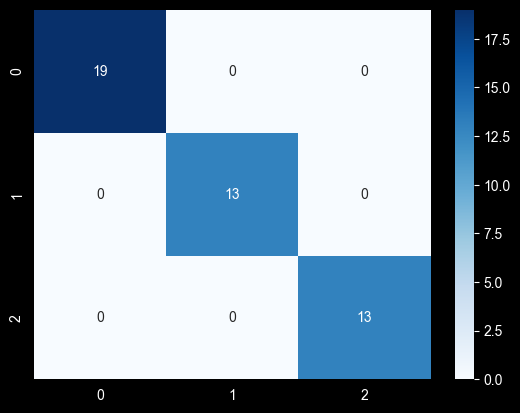

In [24]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True,cmap="Blues")

3-CatBoost:

CatBoost is particularly effective for datasets with categorical features. It employs symmetric decision trees and a unique encoding method that considers target values, making it superior in handling categorical data without preprocessing.

for other you need to encode then use them like XGBoost

CatBoost is NOT only for categorical data. It handles numerical data just as well as any other boosting method. Its "superpower" is handling categorical data better than others — but it works perfectly on numerical-only datasets too.

CatBoost's encoding actually PREVENTS overfitting, unlike traditional One-Hot Encoding which causes it.

works like GD

CatBoost seamlessly handles both categorical and numerical features without manual encoding by using Ordered Target Encoding internally. This makes it ideal for large-scale datasets with many independent features — you just pass the raw data, specify which columns are categorical, and CatBoost does the rest efficiently and without overfitting.

It also uses Symmetric Weighted Quantile Sketch (SWQS) algorithm which helps in handles missing values, reduces overfitting and improves model performance like XGboost






In [44]:
from catboost import CatBoostClassifier

model = CatBoostClassifier(
    # Core
    iterations=200,              # Number of trees
    learning_rate=0.03,          # Step size
    depth=6,                     # Tree depth
    l2_leaf_reg=3.0,             # L2 regularization

    # Categorical
    cat_features=['city', 'product'],  # ← MUST specify!
    one_hot_max_size=10,        # One-hot small categories

    # Regularization
    subsample=0.8,              # 80% data per tree
    random_strength=1.0,        # Prevent overfitting
    min_child_samples=20,       # Min samples in leaf

    # Speed
    task_type='CPU',            # or 'GPU'
    thread_count=-1,            # Use all cores

    # Early stopping
    early_stopping_rounds=10,
    use_best_model=True,

    random_seed=42,
    verbose=False               # Suppress output
)

#In simple terms: If a categorical column has 10 or fewer unique values, CatBoost will use One-Hot Encoding. If it has more than 10, CatBoost uses its Ordered Target Encoding.



In [40]:
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


In [42]:
iris = load_iris()
X = iris.data
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [45]:
model = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    verbose=0
)


model.fit(X_train, y_train)

y_pred = model.predict(X_test)


In [48]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



CatBoost supports GPU-accelerated training which helps speed up the model-building process especially when working with large datasets. This allows models to be trained faster by using the power of graphics cards (GPUs).

CatBoost also uses smart techniques to avoid overfitting such as ordered boosting, random feature combinations and strong boosting methods. These help the model perform well even on new, unseen data.





4- LightGBM:

LightGBM is a gradient boosting framework that uses leaf-wise tree growth instead of level-wise growth, making it faster and more memory-efficient than traditional gradient boosting. It excels with large datasets and supports categorical features efficiently using histogram-based algorithms.

LightGBM is a high-performance gradient boosting framework by Microsoft that uses histogram-based algorithms, leaf-wise tree growth, and Gradient-based One-Side Sampling (GOSS) to achieve exceptional speed, memory efficiency, and accuracy, especially on large datasets.

LightGBM's Data Structure API converts raw data (Pandas/NumPy) into a special Dataset object that is optimized for fast, memory-efficient training. It handles categorical features, weights, and validation data automatically, making it the recommended way to feed data into LightGBM.

In [ ]:
import lightgbm as lgb

params = {
    # Core (Big 5)
    'num_leaves': 31,          #Max leaves per tree (leaf-wise growth)
    'learning_rate': 0.05,
    'n_estimators': 200,
    'max_depth': 6,
    'min_child_samples': 20,  #Min data in a leaf

    # Regularization
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,

    # Sampling
    'feature_fraction': 0.8,  #Fraction of features per tree
    'bagging_fraction': 0.8,  #Fraction of data per tree

    'bagging_freq': 5,    #Frequency of bagging (0 = no bagging)

    # Task
    'objective': 'binary',
    'metric': 'auc',

    # Speed
    'n_jobs': -1,
    'max_bin': 255,

    # Early stopping
    'early_stopping_rounds': 10,

    'random_state': 42,
    'verbose': -1
}



In [54]:
import lightgbm as lgb
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert to LightGBM Dataset
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

# Parameters
params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.9
}

# Train
model = lgb.train(params, train_data, valid_sets=[test_data], num_boost_round=100)

# Predict
y_pred = model.predict(X_test)
y_pred_binary = (y_pred > 0.5).astype(int)

print(f"Accuracy: {accuracy_score(y_test, y_pred_binary):.4f}")

[LightGBM] [Info] Number of positive: 286, number of negative: 169
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000282 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4548
[LightGBM] [Info] Number of data points in the train set: 455, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.628571 -> initscore=0.526093
[LightGBM] [Info] Start training from score 0.526093
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

## Points

1-XGBoost is better than standard Gradient Boosting because it is faster due to optimized parallel computation, it includes L1 and L2 regularization to reduce overfitting, and it uses second-order gradients for more accurate optimization. It also handles missing values automatically.

2-Level-wise = grow evenly
Leaf-wise = grow greedily (best node first)



In [ ]:
as ml ai engineer you need math of enesemblig as well later you will 